In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\Laveena\Downloads\archive (3)\healthcare-dataset-stroke-data.csv")

In [3]:
df.shape

(5110, 12)

In [4]:
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [8]:
df.describe(include='O')

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


In [12]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [9]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [13]:
df['bmi']=df['bmi'].fillna(df['bmi'].median())

In [14]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [17]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].unique())


 gender
['Male' 'Female' 'Other']

 ever_married
['Yes' 'No']

 work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

 Residence_type
['Urban' 'Rural']

 smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


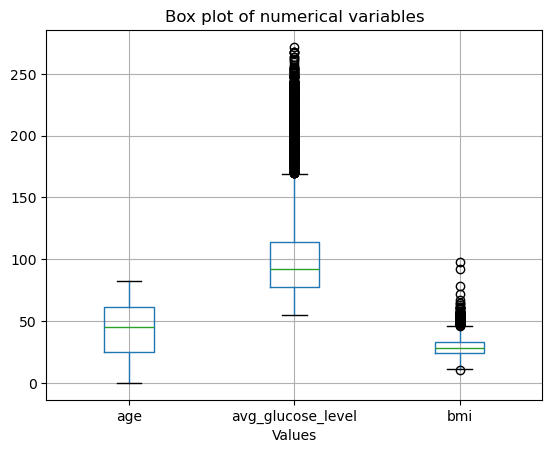

In [20]:
df[['age','avg_glucose_level','bmi']].boxplot()
plt.title('Box plot of numerical variables')
plt.xlabel('Values')
plt.show()

## Outlier Analysis

Box plots were used to identify potential outliers in the numerical variables.

The `avg_glucose_level` and `bmi` columns contain several statistical outliers based on the box plot. These values were retained because they may represent genuine healthcare measurements rather than data-entry errors.

The `age` column does not show significant statistical outliers.

Therefore, no observations were removed solely based on the box-plot results.

In [21]:
df.to_csv("healthcare_stroke_cleaned.csv", index=False)

In [22]:
import os
os.path.exists("healthcare_stroke_cleaned.csv")

True

## Data Preparation Summary

### Steps Completed

- Loaded the healthcare stroke dataset.
- Checked the dataset shape and structure.
- Identified missing values.
- Filled missing BMI values using the median.
- Verified that no missing values remain.
- Checked for duplicate records.
- Verified the data types.
- Checked categorical values for consistency.
- Reviewed numerical statistics using `describe()`.
- Used box plots to identify potential outliers.
- Saved the cleaned dataset as `healthcare_stroke_cleaned.csv`.

### Outlier Handling

Potential outliers were identified using box plots. The detected outliers were not automatically removed because unusual healthcare measurements may represent genuine patient observations. The values were therefore retained unless they were determined to be invalid.

### Assumptions

- Median imputation was used for missing BMI values because BMI is numerical and the median is less sensitive to extreme values.
- Duplicate records were checked and none were found.
- Categorical values were reviewed for unexpected categories.
- Numerical variables were reviewed for potential outliers.
- Potential outliers were retained because an unusual medical measurement does not necessarily indicate an incorrect record.